In [1]:
import yfinance as yf
import pandas as pd

# 1. Select the stock (Apple)
ticker = 'AAPL'

# 2. Download historical data
# We'll take the last 2 years of data
df = yf.download(ticker, start="2024-01-01", end="2026-05-10")

print(f"✅ Downloaded {len(df)} days of stock data for {ticker}!")
df.head()

[*********************100%***********************]  1 of 1 completed

✅ Downloaded 590 days of stock data for AAPL!


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2024-01-02,183.562180,186.330843,181.831767,185.055273,82488700
2024-01-03,182.187744,183.799505,181.376915,182.158081,58414500
2024-01-04,179.873932,181.040717,178.855462,180.111236,71983600
2024-01-05,179.152100,180.714417,178.153410,179.953046,62379700
2024-01-08,183.483078,183.522639,179.468523,180.051916,59144500


In [2]:
# We want to predict the NEXT day's closing price
df['Next_Close'] = df['Close'].shift(-1)

# Drop the very last row because we don't know tomorrow's price yet!
df = df.dropna()

# Features: The clues we use (Open, High, Low, Volume)
X = df[['Open', 'High', 'Low', 'Volume']]

# Target: What we want to guess
y = df['Next_Close']

print("Target column created. The AI now has 'answers' to practice with.")

Target column created. The AI now has 'answers' to practice with.


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split: 80% for learning, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("📈 Model trained! It's ready to guess stock prices.")

📈 Model trained! It's ready to guess stock prices.


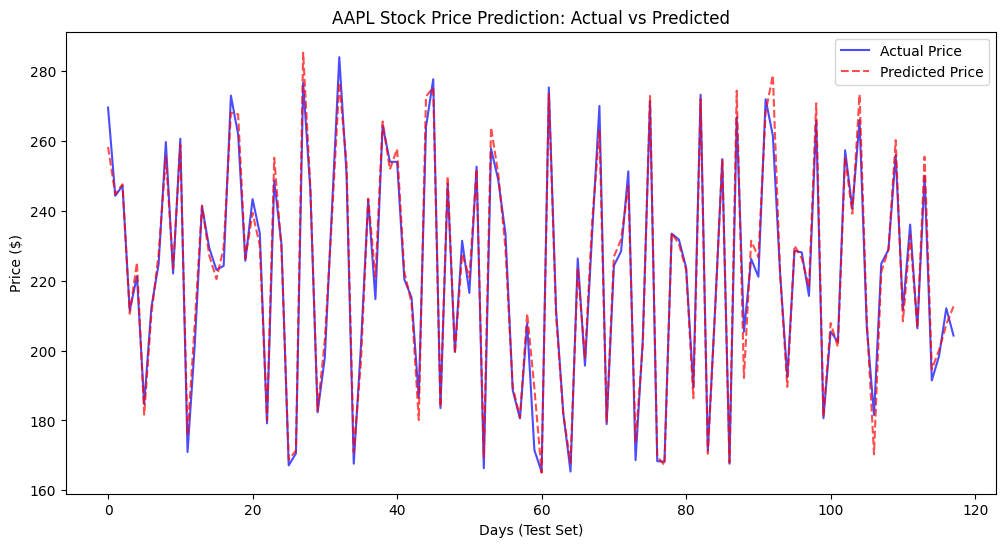

In [4]:
import matplotlib.pyplot as plt

# Make predictions
predictions = model.predict(X_test)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Price', color='blue', alpha=0.7)
plt.plot(predictions, label='Predicted Price', color='red', linestyle='--', alpha=0.7)
plt.title(f'{ticker} Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Days (Test Set)')
plt.ylabel('Price ($)')
plt.legend()
plt.show()